In [1]:
from primordialpy.background import Background
from primordialpy.model import PotentialFunction
from primordialpy.perturbations import  Perturbations
from primordialpy.pbhabundance import PBHAbundance
from primordialpy.pbhconstraints import PBHConstraints

import matplotlib.pyplot as plt

In [2]:

# 1. Definimos la forma del potencial (es la misma para todos)
V_string = 'V0*(tanh(phi/sqrt(6)))**2*(1 + A*(sech((phi - phi0)/sigma))**2)'

# 2. Creamos el "Diccionario de Casos"
# Aquí pones los parámetros que cambian en cada notebook.
# Pongo valores inventados cercanos a los tuyos para el ejemplo.
cases = {
    "Case 1 (Fuerte)": {
        'params': {'V0': 1.448e-10, 'A': 2.044880e-3, 'phi0': 4.850001, 'sigma': 2.524999e-2},
        'phi_ini': 6.3,
        'color': 'firebrick'
    },
    "Case 2 (Medio)": {
        'params': {'V0': 1.495e-10, 'A': 1.080552e-3,   'phi0': 5.301327, 'sigma': 1.940550e-2},
        'phi_ini': 6.3,
        'color': 'teal'
    },
    "Case 3 (Débil)": {
        'params': {'V0': 1.420e-10, 'A': 6.402075e-4,   'phi0': 5.580000, 'sigma': 1.428997e-2},
        'phi_ini': 6.3,
        'color': 'navy'
    }
}

# 3. El Bucle de Simulación (The Factory)
results = {} # Aquí guardaremos los objetos calculados

print("Iniciando simulaciones...")
for name, config in cases.items():
    print(f"--> Corriendo: {name}")
    
    # A) Configurar Modelo
    pot = PotentialFunction.from_string(V_string, param_values=config['params'])
    
    # B) Background
    bg = Background(pot, phi0=config['phi_ini'])
    bg.solver()
    
    # C) Perturbaciones
    pert = Perturbations(pot, bg, scale='PBH', N_CMB=60)
    pert.Power_spectrum()
    
    # D) Abundancia
    pbh = PBHAbundance(pert, delta_c= 0.4, gamma=0.2, gstar= 107.5)
    m_pbh, f_pbh = pbh.fPBH()
    
    # Guardamos todo lo necesario en el diccionario 'results'
    results[name] = {
        'm_pbh': m_pbh,
        'f_pbh': f_pbh,
        'color': config['color']
    }

print("¡Simulaciones terminadas!")

Iniciando simulaciones...
--> Corriendo: Case 1 (Fuerte)


Computing P(k): 100%|██████████| 1000/1000 [00:44<00:00, 22.38it/s]


fPBH_peak = 0.9661364130354699
MPBH_peak = 1.5881318171524883e-13 M⊙
--> Corriendo: Case 2 (Medio)


Computing P(k): 100%|██████████| 1000/1000 [00:47<00:00, 21.10it/s]


fPBH_peak = 0.0008325842858137519
MPBH_peak = 0.009221488290673341 M⊙
--> Corriendo: Case 3 (Débil)


Computing P(k): 100%|██████████| 1000/1000 [00:52<00:00, 19.01it/s]


fPBH_peak = 0.009840042762011201
MPBH_peak = 10.607933991970969 M⊙
¡Simulaciones terminadas!


  [OK] Loaded data: Evap
  [OK] Loaded data: HSC
  [OK] Loaded data: LIGO


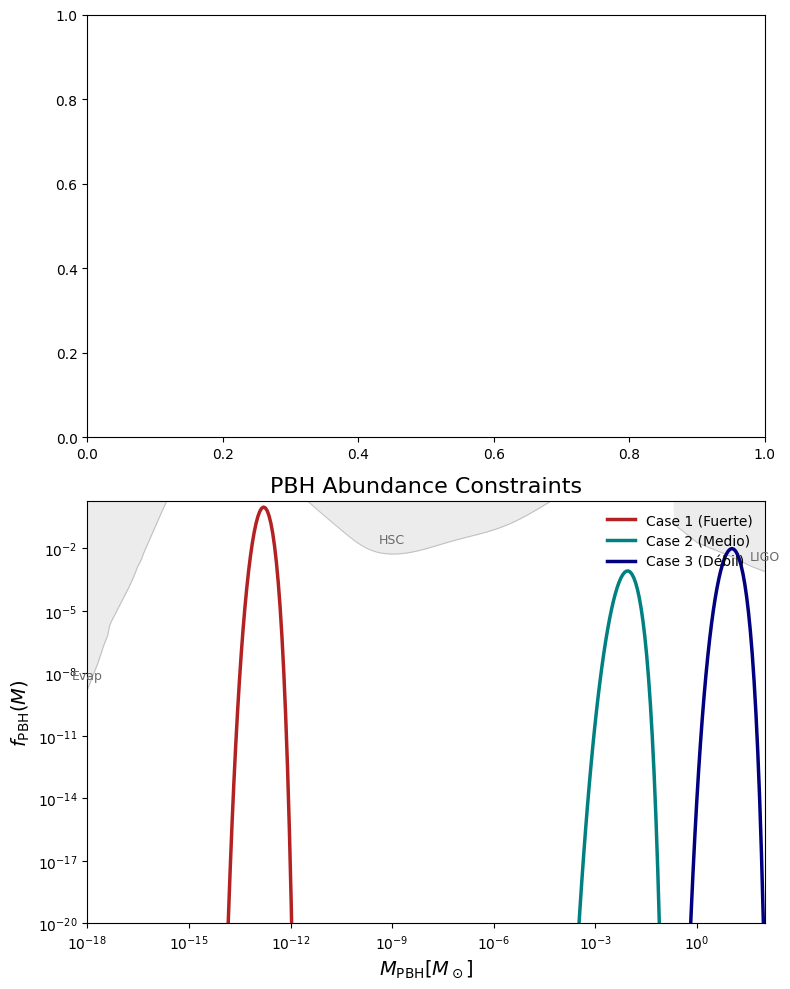

In [3]:
# Configuramos un panel de 2 gráficos (Espectro arriba, Abundancia abajo)
fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharex=False)
ax_spec, ax_pbh = axes

# # --- GRÁFICO 1: Espectro de Potencias ---
# for name, res in results.items():
#     ax_spec.loglog(res['k'], res['P_R'], 
#                    label=name, color=res['color'], linewidth=2)

# ax_spec.set_ylabel(r'$\mathcal{P}_{\mathcal{R}}(k)$', fontsize=14)
# ax_spec.set_xlabel(r'$k$ [Mpc$^{-1}$]', fontsize=14)
# ax_spec.set_title('Comparison of Power Spectra', fontsize=16)
# ax_spec.legend(frameon=False)
# ax_spec.grid(alpha=0.2)


# --- GRÁFICO 2: Abundancia de PBHs ---

# A) Primero cargamos las cotas de fondo (usando tu clase)
bounds = PBHConstraints() # Asume que ya arreglaste lo de la carpeta automática
try:
    bounds.add_bound('Evap', 'evaporation.txt')
    bounds.add_bound('HSC', 'hsc.txt') 
    bounds.add_bound('LIGO', 'ligo.txt')
    bounds.plot(ax_pbh) # Grafica el fondo gris
except:
    print("No se encontraron cotas, graficando solo modelos.")

# B) Graficamos los modelos encima
for name, res in results.items():
    # Filtramos para no graficar ceros y ensuciar el loglog
    mask = res['f_pbh'] > 1e-30 
    ax_pbh.loglog(res['m_pbh'][mask], res['f_pbh'][mask], 
                  color=res['color'], linewidth=2.5, label=name)

ax_pbh.set_ylim(bottom=1e-20, top=2.0)
ax_pbh.set_xlim(1e-18, 100) # Ajusta según donde caigan tus picos
ax_pbh.set_title('PBH Abundance Constraints', fontsize=16)
ax_pbh.legend(loc='upper right', frameon=False, fontsize=10)

plt.tight_layout()
plt.show()